In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

Load Datasets

In [3]:
X_train = torch.tensor(np.load("X_train.npy"), dtype=torch.float32)
y_train = torch.tensor(np.load("y_train.npy"), dtype=torch.float32).view(-1)

X_test = torch.tensor(np.load("X_test.npy"), dtype=torch.float32)
y_test = torch.tensor(np.load("y_test.npy"), dtype=torch.float32).view(-1)


Model

In [4]:
class ISNN2(nn.Module):
    def __init__(self, hidden_dim=15):
        super(ISNN2, self).__init__()

        self.softplus = nn.Softplus()
        self.sigmoid = nn.Sigmoid()

        # branches
        self.y_layer = nn.Linear(1, hidden_dim)
        self.z_layer = nn.Linear(1, hidden_dim)
        self.t_layer = nn.Linear(1, hidden_dim)

        # x branch
        self.x_layer1 = nn.Linear(4, hidden_dim)
        self.x_layer2 = nn.Linear(hidden_dim + 1 + 3 * hidden_dim, hidden_dim)

        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, X):
        x0 = X[:, 0:1]
        y0 = X[:, 1:2]
        t0 = X[:, 2:3]
        z0 = X[:, 3:4]

        # branch processing
        y = self.softplus(self.y_layer(y0))
        z = self.sigmoid(self.z_layer(z0))
        t = self.sigmoid(self.t_layer(t0))

        # first x layer
        combined0 = torch.cat([x0, y0, z0, t0], dim=1)
        x = self.softplus(self.x_layer1(combined0))

        # skip connections layer
        combined1 = torch.cat([x, x0, y, z, t], dim=1)
        x = self.softplus(self.x_layer2(combined1))

        return self.output_layer(x)

Training

In [5]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        preds = model(X_train)

        loss = loss_fn(preds.view(-1), y_train)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # test
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test)
            test_loss = loss_fn(test_preds.view(-1), y_test)
            test_losses.append(test_loss.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Train Loss = {loss.item():.4f}, Test Loss = {test_loss.item():.4f}")

    return train_losses, test_losses

True Function

In [6]:
def true_function(v):
    return (
        np.exp(-0.5 * v)
        + np.log(1 + np.exp(0.4 * v))
        + np.tanh(v)
        + np.sin(v)
        - 0.4
    )

Behaviour Plot

In [7]:
def plot_behavior(model):
    values = np.linspace(0, 6, 200)

    X_plot = np.stack([values, values, values, values], axis=1)
    X_plot_tensor = torch.tensor(X_plot, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        preds = model(X_plot_tensor).view(-1).numpy()

    true_vals = true_function(values)

    plt.plot(values, true_vals, label="True Function", linewidth=2)
    plt.plot(values, preds, label="Model Prediction", linestyle="--")

    plt.title("Behavior Plot (ISNN-2)")
    plt.xlabel("Input (x=y=t=z)")
    plt.ylabel("Output")

    plt.legend()
    plt.grid()
    plt.show()

Run

In [8]:
model = ISNN2(hidden_dim=15)

train_losses, test_losses = train_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=1000
)

Epoch 0: Train Loss = 7.7009, Test Loss = 7.1661
Epoch 100: Train Loss = 0.4206, Test Loss = 0.9216
Epoch 200: Train Loss = 0.3049, Test Loss = 0.7163
Epoch 300: Train Loss = 0.2449, Test Loss = 0.5778
Epoch 400: Train Loss = 0.2213, Test Loss = 0.5041
Epoch 500: Train Loss = 0.2082, Test Loss = 0.4477
Epoch 600: Train Loss = 0.1914, Test Loss = 0.3750
Epoch 700: Train Loss = 0.1727, Test Loss = 0.3135
Epoch 800: Train Loss = 0.1524, Test Loss = 0.2709
Epoch 900: Train Loss = 0.1313, Test Loss = 0.2381


Plot losses

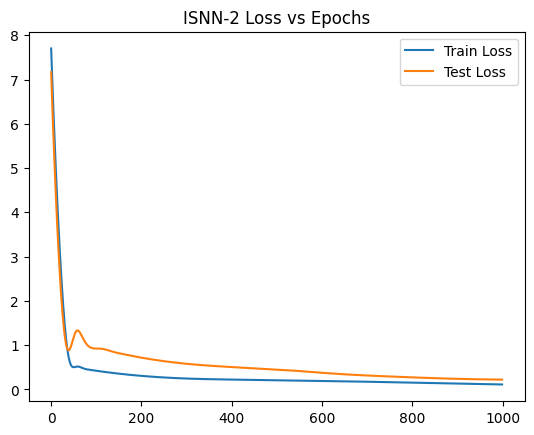

In [9]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("ISNN-2 Loss vs Epochs")
plt.show()


Behaviour Plot

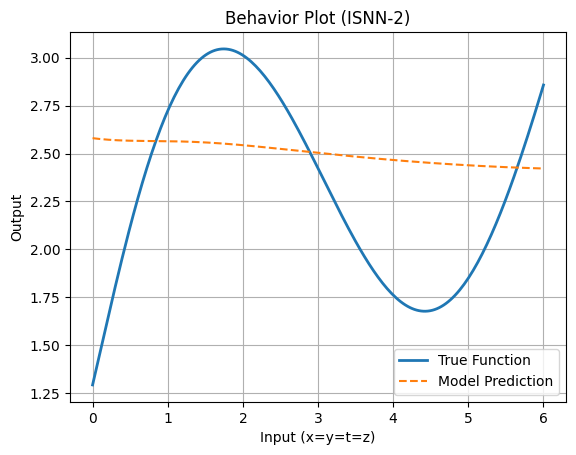

In [10]:
plot_behavior(model)